# Visualize Monte Carlo for Markets

In reality, market returns exhibit more fat tails than a normal distribution.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

Making some simplifying assumptions about stocks following $\sim \mathcal{N}(.1, (.18)^2)$

$\text{bonds} \sim \mathcal{N}(.04, (.06)^2)$

$\text{real estate}  \sim \mathcal{N}(.07, (.12)^2)$

$\text{commodities}  \sim \mathcal{N}(.05, (.20)^2)$

In [3]:
years = 50
n_sims = 1000
initial_investment = 10000

# Illustrative annual return assumptions
assets = {
    'Stocks': {'mu': 0.10, 'sigma': 0.18},
    'Bonds': {'mu': 0.04, 'sigma': 0.06},
    'Real Estate': {'mu': 0.07, 'sigma': 0.12},
    'Commodities': {'mu': 0.05, 'sigma': 0.20},
}

def simulate_paths(mu, sigma, years, n_sims, initial):
    # Simulate annual returns
    returns = np.random.normal(mu, sigma, size=(n_sims, years))
    
    # Convert returns into wealth paths
    wealth = np.zeros((n_sims, years + 1))
    wealth[:, 0] = initial
    for t in range(1, years + 1):
        wealth[:, t] = wealth[:, t - 1] * (1 + returns[:, t - 1])
    
    return wealth

In [4]:
results = {}
for asset, params in assets.items():
    results[asset] = simulate_paths(
        params['mu'],
        params['sigma'],
        years,
        n_sims,
        initial_investment
    )

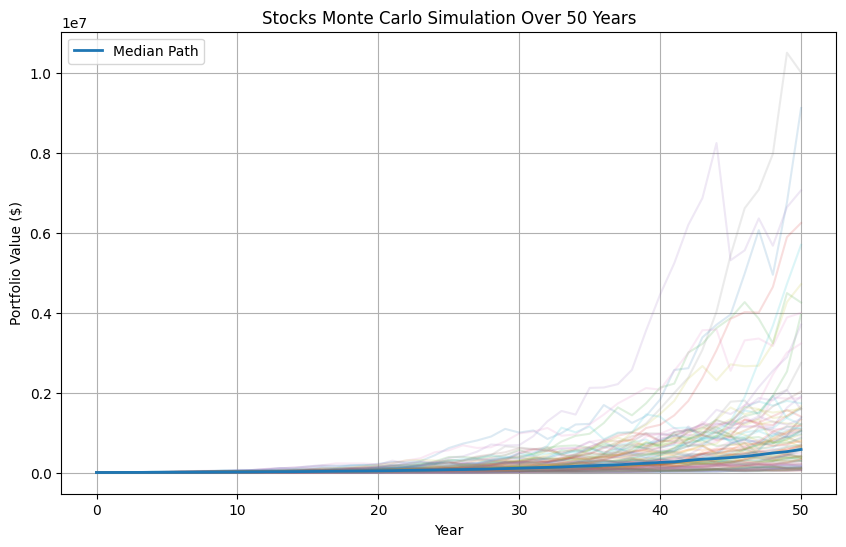

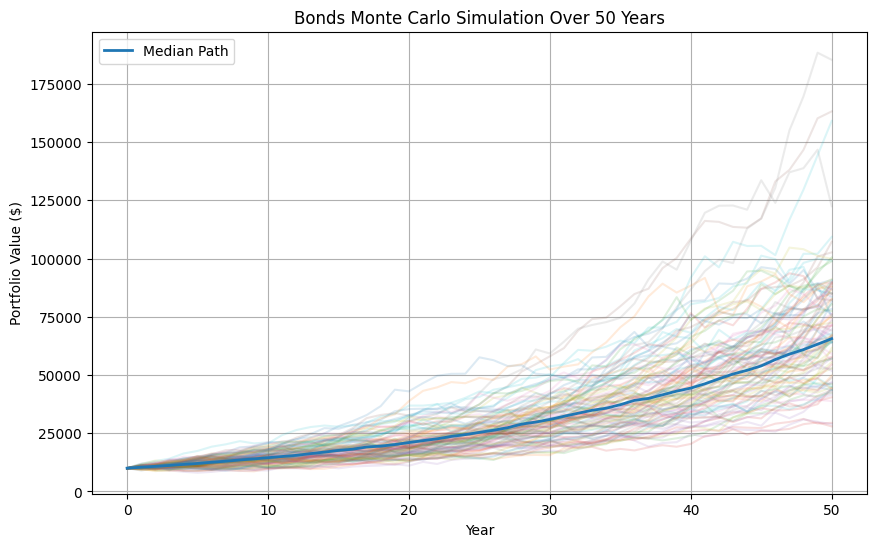

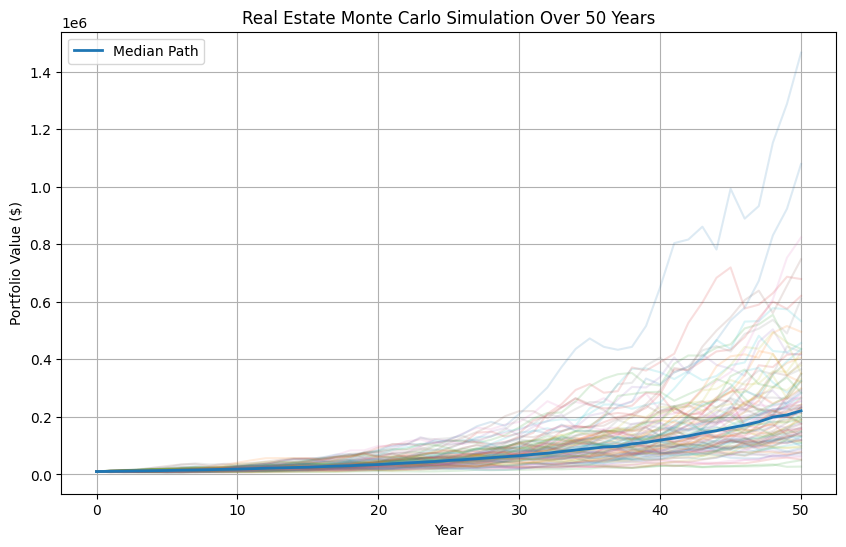

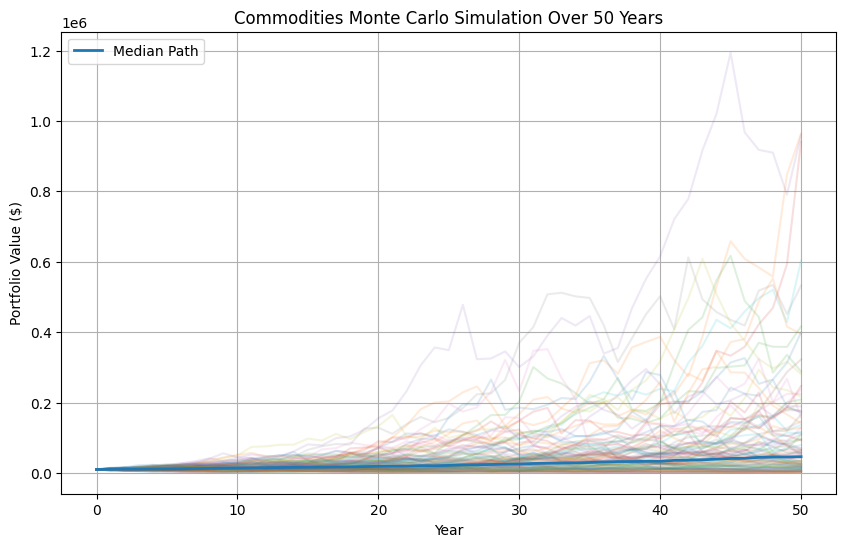

In [5]:
# Plot simulated paths
for asset, wealth in results.items():
    plt.figure(figsize=(10, 6))
    for i in range(100):  # plot only first 100 paths so it doesn't get too cluttered
        plt.plot(range(years + 1), wealth[i], alpha=0.15)
    
    median_path = np.median(wealth, axis=0)
    plt.plot(range(years + 1), median_path, linewidth=2, label='Median Path')
    
    plt.title(f'{asset} Monte Carlo Simulation Over {years} Years')
    plt.xlabel('Year')
    plt.ylabel('Portfolio Value ($)')
    plt.legend()
    plt.grid(True)
    plt.show()

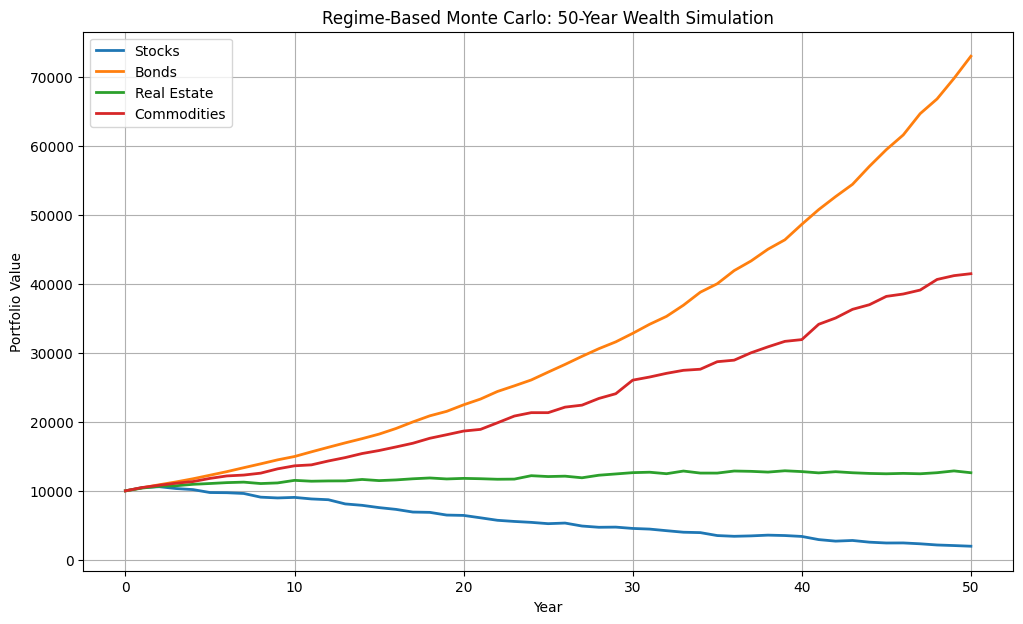

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import random

np.random.seed(42)

years = 50
n_sims = 1000
initial = 10000

# Define macro regimes
regimes = {
    "Expansion": {
        "prob": 0.7,
        "assets": {
            "Stocks": (0.10, 0.15),
            "Bonds": (0.04, 0.05),
            "Real Estate": (0.07, 0.10),
            "Commodities": (0.05, 0.18),
        }
    },
    "Recession": {
        "prob": 0.2,
        "assets": {
            "Stocks": (-0.15, 0.25),
            "Bonds": (0.06, 0.07),
            "Real Estate": (-0.05, 0.15),
            "Commodities": (0.02, 0.22),
        }
    },
    "Crisis": {
        "prob": 0.1,
        "assets": {
            "Stocks": (-0.30, 0.35),
            "Bonds": (0.02, 0.10),
            "Real Estate": (-0.20, 0.25),
            "Commodities": (0.10, 0.30),
        }
    }
}

regime_names = list(regimes.keys())
regime_probs = [regimes[r]["prob"] for r in regime_names]

def simulate_asset(asset_name):
    wealth = np.zeros((n_sims, years + 1))
    wealth[:, 0] = initial

    for sim in range(n_sims):
        for t in range(1, years + 1):

            regime = np.random.choice(regime_names, p=regime_probs)

            mu, sigma = regimes[regime]["assets"][asset_name]

            r = np.random.normal(mu, sigma)

            wealth[sim, t] = wealth[sim, t - 1] * (1 + r)

    return wealth

results = {}

for asset in ["Stocks", "Bonds", "Real Estate", "Commodities"]:
    results[asset] = simulate_asset(asset)

plt.figure(figsize=(12, 7))

for asset, wealth in results.items():
    median = np.median(wealth, axis=0)
    plt.plot(median, linewidth=2, label=asset)

plt.title("Regime-Based Monte Carlo: 50-Year Wealth Simulation")
plt.xlabel("Year")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()